# 3-2 다층 퍼셉트론으로 구현한 XOR 게이트 시뮬레이터

본 노트북은 본문 3-2 절의 코드 예제([코드 3-1] ~ [코드 3-7])를 절 흐름 그대로 모은 것이다. 두 개의 입력을 받아 하나의 출력을 내는 다층 퍼셉트론으로 XOR 게이트를 시뮬레이션한다.

본문 [코드 3-2](`WrongMLP1`), [코드 3-3](`FalseMLP2`) 는 의도적으로 잘못 만든 모델 예시이다. 두 코드는 인스턴스 생성과 호출 결과를 짧게 보여 주는 정도로만 다룬다.

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 3-1] 다층 퍼셉트론 모델 클래스 정의

은닉층과 출력층 두 개의 선형 계층(`nn.Linear`)과 시그모이드 활성화 계층(`nn.Sigmoid`)을 정의해 `forward()` 에서 데이터 흐름 순서대로 배치한다. 활성화 계층은 파라미터가 없으므로 객체 하나를 만들어 두 번 재사용한다.

In [3]:
# 코드 3-1 - 다층 퍼셉트론 모델 클래스 정의

# 은닉층 하나를 가진 다층 퍼셉트론 모델 클래스
class MLP(nn.Module):
    # 은닉층과 출력층 두 개의 선형 계층, 시그모이드 활성화 계층 정의
    def __init__(self):
        super().__init__()
        self.hidden_layer = nn.Linear(2, 2)     # 은닉층: in_features=2, out_features=2
        self.output_layer = nn.Linear(2, 1)     # 출력층: in_features=2, out_features=1
        # 시그모이드 활성화 계층은 파라미터가 없어 재사용 가능
        self.activation = nn.Sigmoid()          # 활성화 계층

    # 데이터 흐름 순서대로 모델을 조립
    # hidden_layer(은닉층) -> activation(활성화 계층) -> output_layer(출력층) -> activation(활성화 계층)
    def forward(self, x):
        x = self.hidden_layer(x)        # 은닉층: (4, 2) -> (4, 2)
        x = self.activation(x)          # 활성화 계층: 형태가 바뀌지 않음
        x = self.output_layer(x)        # 출력층: (4, 2) -> (4, 1)
        x = self.activation(x)          # 활성화 계층
        return x

## [코드 3-2] 파라미터 계층 객체는 한 번만 사용해야 한다 (설명용)

하나의 `nn.Linear` 계층 객체를 은닉층과 출력층 두 위치에서 호출하면 가중치가 공유되어 학습이 정상적으로 진행되지 않는다. 인스턴스 생성과 구조 출력만 짧게 보여 준다.

In [4]:
# 코드 3-2 - 파라미터 계층 객체는 한 번만 사용해야 한다

# 잘못 만들어진 첫 번째 MLP 모델 클래스
class WrongMLP1(nn.Module):     
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(2, 2)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        x = self.layer(x)
        x = self.activation(x)
        x = self.layer(x)       # 잘못된 객체 사용: 은닉층과 출력층에 같은 객체를 사용
        x = self.activation(x)
        return x

# 인스턴스 생성과 호출은 가능하지만, 두 선형 계층의 파라미터가 공유되어 학습이 잘 안 된다.
wrong = WrongMLP1()
print(wrong)

WrongMLP1(
  (layer): Linear(in_features=2, out_features=2, bias=True)
  (activation): Sigmoid()
)


## [코드 3-3] 연결된 계층은 입력·출력 형태가 일치해야 한다 (설명용)

은닉층 출력 형태와 출력층 입력 형태가 다르면 호출 시 예외가 발생한다. (n, 3) 형태를 출력하는 은닉층과 (n, 2) 형태를 입력받는 출력층을 연결해 예외 발생을 확인한다.

In [5]:
# 코드 3-3 - 연결된 두 계층은 이전 계층의 출력과 다음 계층의 입력 형태가 같아야 한다

# 잘못 만들어진 두 번째 MLP 모델 클래스
class FalseMLP2(nn.Module):     
    def __init__(self):
        super().__init__()
        self.hidden_layer = nn.Linear(2, 3)     # 출력이 세 개인 은닉층
        self.output_layer = nn.Linear(2, 1)     # 입력이 두 개인 출력층
        self.activation = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden_layer(x)                # (N, 3) 형태의 텐서 출력
        x = self.activation(x)                  # (N, 3) 형태 출력: 텐서 형태 유지
        x = self.output_layer(x)                # (N, 3) 형태의 텐서를 입력하면 예외 발생
        x = self.activation(x)
        return x


# 모델 호출 시 예외 발생 확인
false_model = FalseMLP2()
X_sample = torch.tensor([[0., 0.], [1., 1.]])
false_model(X_sample)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x3 and 2x1)

## [코드 3-4] 모델 인스턴스 생성과 요약 정보

클래스로 정의한 모델은 인스턴스를 생성해 사용한다. `torchinfo.summary()` 로 입력 형태에 따른 각 계층의 출력 형태와 파라미터 수를 확인한다.

> 참고: 본문 캡션은 "3개의 뉴런을 가진 은닉층" 이라 적혀 있으나 [코드 3-1] 의 `nn.Linear(2, 2)` 는 은닉층 뉴런이 2 개이다. 본 노트북은 [코드 3-1] 의 코드 정의를 그대로 따르므로 은닉층 출력은 `[4, 2]` 이다. (본문 캡션·출력의 `[4, 3]` 과의 차이는 `_book` 에 기록한다.)

In [6]:
# 코드 3-4 - MLP 클래스로 모델 객체를 만들고 구조를 출력

model = MLP()                                       # 모델 인스턴스 생성
summary(model, input_size=(4, 2), device='cpu')     # 모델 요약 정보 출력

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [4, 1]                    --
├─Linear: 1-1                            [4, 2]                    6
├─Sigmoid: 1-2                           [4, 2]                    --
├─Linear: 1-3                            [4, 1]                    3
├─Sigmoid: 1-4                           [4, 1]                    --
Total params: 9
Trainable params: 9
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## [코드 3-5] 학습 하이퍼파라미터·옵티마이저·손실 함수

파라미터 최적화에 Adam 옵티마이저(`optim.Adam`) 를 학습률 0.01 로 사용하고, 손실 함수로 평균 제곱 오차(`nn.MSELoss`) 를 사용한다.

In [7]:
# 코드 3-5 - MLP 학습에 사용하는 하이퍼파라미터, 옵티마이저, 손실 함수
LR = 0.01           # 학습률
EPOCHS = 1000       # 전체 학습 에포크

# Adam 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=LR)
# 평균 제곱 오차 손실 함수
criterion = nn.MSELoss()

## 학습 함수 정의 (`train_with_loss`)

본문 [코드 3-6] 은 `train_with_loss(model, X, Y_true, criterion, optimizer, epochs)` 함수를 이미 정의되어 있다고 가정하고 호출한다. 본 노트북에서는 이 학습 함수를 한 번 정의해 두고 이후 절(3-3) 까지 재사용한다. 학습 로그는 공통 표준인 `common.EpochLogger` 로 출력하며(§7.6), 함수는 학습이 끝난 뒤 `log.summary()`(최적 에포크·전체 학습 시간) 와 `log.plot()`(학습 곡선) 을 호출할 수 있도록 `log` 객체를 반환한다.

In [ ]:
# 참고 - 코드 3-6 학습을 위한 학습 함수

# 데이터 전체를 매 에포크마다 한 번에 학습하는 학습 함수
def train(model, X, Y_true, criterion, optimizer, epochs):

    # 표준 학습 로거 설정
    log = common.EpochLogger(
        epochs, columns=('손실',), formats=('{:.4f}',),
    )
    model.train()                           # 학습 모드로 전환
    for epoch in range(1, epochs + 1):
        Y_pred = model(X)
        loss = criterion(Y_pred, Y_true)    # 손실 계산 (순전파)
        optimizer.zero_grad()               # 기울기 초기화
        loss.backward()                     # 기울기 계산 (역전파)
        optimizer.step()                    # 파라미터 갱신 (최적화)
        log.row(epoch, loss.item())         # 에포크별 손실을 표준 학습 로거에 저장하고 로그를 출력
    return log

## [코드 3-6] XOR 데이터를 정의해 모델 학습

XOR 게이트 시뮬레이터의 입력(`X`) 과 정답(`Y_true`) 텐서를 정의하고 모델을 학습한다.

In [ ]:
# 코드 3-6 - XOR 데이터를 정의해 모델 학습

# XOR 게이트 시뮬레이터의 입력과 정답 텐서
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
Y_true = torch.tensor([[0.], [1.], [1.], [0.]])

# 모델 학습: 표준 학습 로거 객체를 반환
log = train(model, X, Y_true, criterion, optimizer, EPOCHS)

    epoch         손실     시간
   1/1000       0.2723     0:00
 100/1000       0.2494     0:00
 200/1000       0.2374     0:00
 300/1000       0.1913     0:00
 400/1000       0.1216     0:00
 500/1000       0.0467     0:00
 600/1000       0.0223     0:00
 700/1000       0.0133     0:00
 800/1000       0.0090     0:00
 900/1000       0.0066     0:00
1000/1000       0.0051     0:00


학습 곡선을 시각화해 본다.

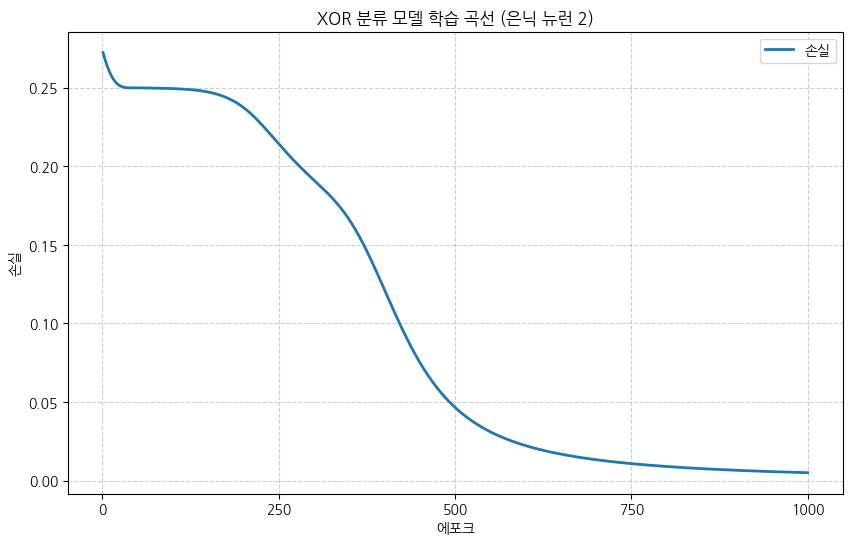

In [10]:
# 참고 - 학습 곡선 시각화 (EpochLogger 표준)
log.plot(title='XOR 분류 모델 학습 곡선 (은닉 뉴런 2)')

## [코드 3-7] 학습된 모델로 예측

시그모이드 출력값은 0~1 사이의 실수이므로, 0.5 를 기준으로 0/1 로 분류해 XOR 결과와 비교한다. 파라미터 초깃값에 따라 결과는 달라질 수 있다.

In [11]:
# 코드 3-7 - XOR 게이트 시뮬레이터를 사용한 예측
model.eval()                            # 평가 모드로 전환
with torch.no_grad():
    prediction = model(X)               # 예측
    print(prediction)                  
    # 0.5를 문턱값으로 0과 1로 분류
    classes = (prediction >= 0.5).int().flatten().tolist()
    print(f'분류 결과: {classes}')     

tensor([[0.0593],
        [0.9324],
        [0.9336],
        [0.0877]])
분류 결과: [0, 1, 1, 0]


## [그림 3-8] / [그림 3-9] 대응 — 다중 초깃값 비교와 은닉 공간 시각화

본문 [그림 3-8] 은 동일 구조(입력 2 - 은닉 2 - 출력 1) 의 MLP 를 서로 다른 파라미터 초깃값으로 학습했을 때, 은닉층 두 뉴런이 만드는 결정 경계 직선이 어떻게 달라지는지 보여 준다. 정상 학습 두 개와 잘못 학습 두 개를 2x2 로 비교한다.

본문 [그림 3-9] 는 첫 번째 정상 모델을 사용해 (좌) 데이터 공간 (x1, x2), (우) 은닉 공간 (h1, h2) 에서의 출력층 결정 경계를 함께 보여 준다.

아래 시각화는 케이스별 subplot 배치가 필요해 `viz` 모듈 함수가 아닌 matplotlib 을 직접 사용한다. 본문 삽입용인 [그림 3-8] 과 [그림 3-9] 셀은 `viz._save_grayscale()` 로 회색조 300DPI PNG 를 저장한다(`03-02_example_01.png`, `03-02_example_02.png`).

정상 분류 1 (seed=1): 4/4 정답, 분류 결과 [0, 1, 1, 0]
정상 분류 2 (seed=4): 4/4 정답, 분류 결과 [0, 1, 1, 0]
실패 분류 1 (seed=5): 2/4 정답, 분류 결과 [0, 1, 0, 1]
실패 분류 2 (seed=7): 3/4 정답, 분류 결과 [0, 1, 1, 1]


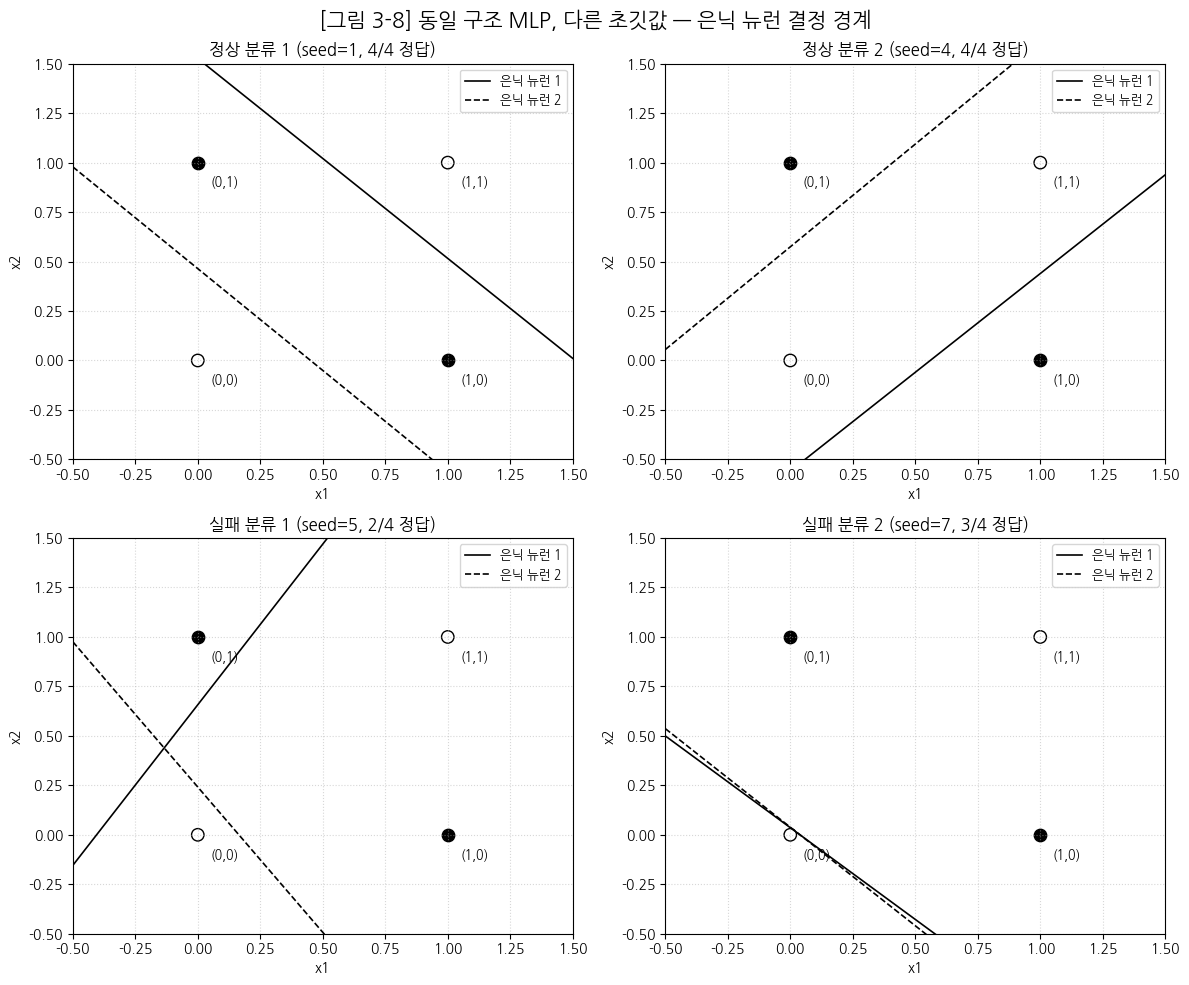

In [12]:
# 참고 - [그림 3-8] 4 개 초깃값 모델 비교 (은닉층 두 뉴런 결정 경계)
import matplotlib.pyplot as plt

# XOR 데이터는 위에서 정의된 X, Y_true 를 그대로 사용
Y_label_list = Y_true.int().flatten().tolist()

# 주어진 시드로 초기화된 모델을 학습한 후 정답 수와 모델을 반환하는 함수
def train_and_eval(seed, epochs=1000, lr=0.01):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    m = MLP()
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.MSELoss()
    for _ in range(epochs):
        pred = m(X)
        loss = crit(pred, Y_true)
        opt.zero_grad()
        loss.backward()
        opt.step()
    m.eval()
    with torch.no_grad():
        pred = m(X)
        cls = (pred >= 0.5).int().flatten().tolist()
        correct_size = sum(int(a == b) for a, b in zip(cls, Y_label_list))
    return m, correct_size, cls

# 정상 분류 시드(42, 1)와 실패 분류 시드(5, 7)를 미리 선택해서 모델 학습
# 독자의 실습 환경에 따라 정상, 실패 분류 시드는 달라질 수 있다.
candidate_seeds = [1, 4, 5, 7]
panel_labels = ['정상 분류 1', '정상 분류 2', '실패 분류 1', '실패 분류 2']
trained = []
for seed, label in zip(candidate_seeds, panel_labels):
    m, correct_size, cls = train_and_eval(seed)
    trained.append((seed, label, m, correct_size, cls))
    print(f'{label} (seed={seed}): {correct_size}/4 정답, 분류 결과 {cls}')


# [그림 3-8]: 2x2 subplot 으로 은닉층 두 뉴런의 결정 경계 비교
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
x_range = np.linspace(-0.5, 1.5, 400)
for ax, (seed, label, m, correct_size, cls) in zip(axes.flat, trained):
    with torch.no_grad():
        hw = m.hidden_layer.weight.detach().numpy()    # (2, 2)
        hb = m.hidden_layer.bias.detach().numpy()      # (2,)
    for x1, x2, y in zip([0., 1., 0., 1.], [0., 0., 1., 1.],
                         Y_label_list):
        face = 'black' if y == 1 else 'none'
        ax.scatter(x1, x2, marker='o', s=80,
                   edgecolor='black', facecolor=face)
        ax.text(x1 + 0.05, x2 - 0.12, f'({int(x1)},{int(x2)})', fontsize=9)
    line_styles = ['-', '--']
    for j in range(2):
        w1, w2, b = hw[j, 0], hw[j, 1], hb[j]
        if w2 == 0:
            ax.axvline(-b / w1, linestyle=line_styles[j], color='black',
                       linewidth=1.2, label=f'은닉 뉴런 {j + 1}')
        else:
            y_vals = -(w1 / w2) * x_range - (b / w2)
            ax.plot(x_range, y_vals, linestyle=line_styles[j],
                    color='black', linewidth=1.2, label=f'은닉 뉴런 {j + 1}')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(f'{label} (seed={seed}, {correct_size}/4 정답)', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
fig.suptitle('[그림 3-8] 동일 구조 MLP, 다른 초깃값 — 은닉 뉴런 결정 경계',
             fontsize=15)
fig.tight_layout()
plt.show()

In [ ]:
# 참고 - [그림 3-8] 본문 삽입용 (분류 영역 표시, 축 눈금 없음)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 본문에 싣는 두 경우만 사용: 시드별로 그림 위에 붙일 제목을 함께 지정
FIGURE_CASES = [(1, '정상 분류 모델'), (5, '오분류 모델')]
model_by_seed = {item[0]: item[2] for item in trained}   # 시드 -> 학습된 모델

# 은닉 뉴런의 출력이 0.5 이상인 영역 = 그 결정 경계가 1로 분류하는 영역
# 격자의 모든 점에 대해 두 은닉 뉴런의 출력을 계산해 영역을 판정한다
GRID_N = 300
grid_axis = np.linspace(-0.5, 1.5, GRID_N)
XX, YY = np.meshgrid(grid_axis, grid_axis)
grid_points = torch.tensor(
    np.stack([XX.ravel(), YY.ravel()], axis=1), dtype=torch.float32,
)

# 빗금 무늬: 결정 경계 1은 가로선, 결정 경계 2는 세로선
#     두 영역이 겹치는 부분은 두 빗금이 함께 그려져 격자 무늬가 된다
HATCHES = ['-----', '|||||']
LINE_STYLES = ['-', '--']
plt.rcParams['hatch.linewidth'] = 0.4

# 본문에 축소해 실으므로 글자를 그림 크기에 비해 크게 잡는다
FONT_SIZE = 16

# 글자를 키운 만큼 범례가 차지하는 높이도 커지므로 그림 높이를 늘려 준다
fig, axes = plt.subplots(1, 2, figsize=(8, 5.3))
for ax, (seed, title) in zip(axes, FIGURE_CASES):
    m = model_by_seed[seed]
    with torch.no_grad():
        hidden = m.activation(m.hidden_layer(grid_points)).numpy()
    weight = m.hidden_layer.weight.detach().numpy()      # (2, 2)
    bias = m.hidden_layer.bias.detach().numpy()          # (2,)

    # 은닉 뉴런별로 1로 분류하는 영역을 빗금으로 채움
    for j in range(2):
        region = hidden[:, j].reshape(GRID_N, GRID_N)
        contour = ax.contourf(
            XX, YY, region, levels=[0.5, 1.0],
            colors='none', hatches=[HATCHES[j]],
        )
        contour.set_edgecolor('black')
        contour.set_linewidth(0)

    # 은닉 뉴런별 결정 경계 직선
    for j in range(2):
        w1, w2, b = weight[j, 0], weight[j, 1], bias[j]
        if w2 == 0:
            ax.axvline(-b / w1, linestyle=LINE_STYLES[j], color='black',
                       linewidth=1.2)
        else:
            ax.plot(grid_axis, -(w1 / w2) * grid_axis - (b / w2),
                    linestyle=LINE_STYLES[j], color='black', linewidth=1.2)

    # XOR 데이터 네 점: 클래스 1은 채운 원, 클래스 0은 빈 원
    for (x1, x2), y in zip(X.tolist(), Y_label_list):
        ax.scatter(x1, x2, marker='o', s=70, zorder=3,
                   edgecolor='black', facecolor='black' if y == 1 else 'white')
        # 빗금 위에서도 읽히도록 좌표 표시에 흰색 배경을 깔아 준다
        ax.text(x1 + 0.07, x2 - 0.17, f'({int(x1)},{int(x2)})', fontsize=FONT_SIZE,
                bbox=dict(facecolor='white', edgecolor='none', pad=0.8))

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([])            # 축의 값 표시 없음
    ax.set_yticks([])
    ax.set_aspect('equal')       # 두 축의 축척을 같게 맞춤
    ax.set_title(title, fontsize=FONT_SIZE)

# 그림 아래에 공통 범례 배치(빗금은 Patch 프록시로 표시)
legend_handles = [
    Line2D([0], [0], color='black', linewidth=1.2, label='결정 경계 1'),
    Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
           label='결정 경계 2'),
    Patch(facecolor='white', edgecolor='black', hatch=HATCHES[0],
          label='결정 경계 1이 1로 분류'),
    Patch(facecolor='white', edgecolor='black', hatch=HATCHES[1],
          label='결정 경계 2가 1로 분류'),
    Patch(facecolor='white', edgecolor='black', hatch=HATCHES[0] + HATCHES[1],
          label='동시에 1로 분류'),
]
fig.tight_layout(rect=[0, 0.25, 1, 1])
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           frameon=False, fontsize=FONT_SIZE)
viz._save_grayscale(fig)
plt.show()

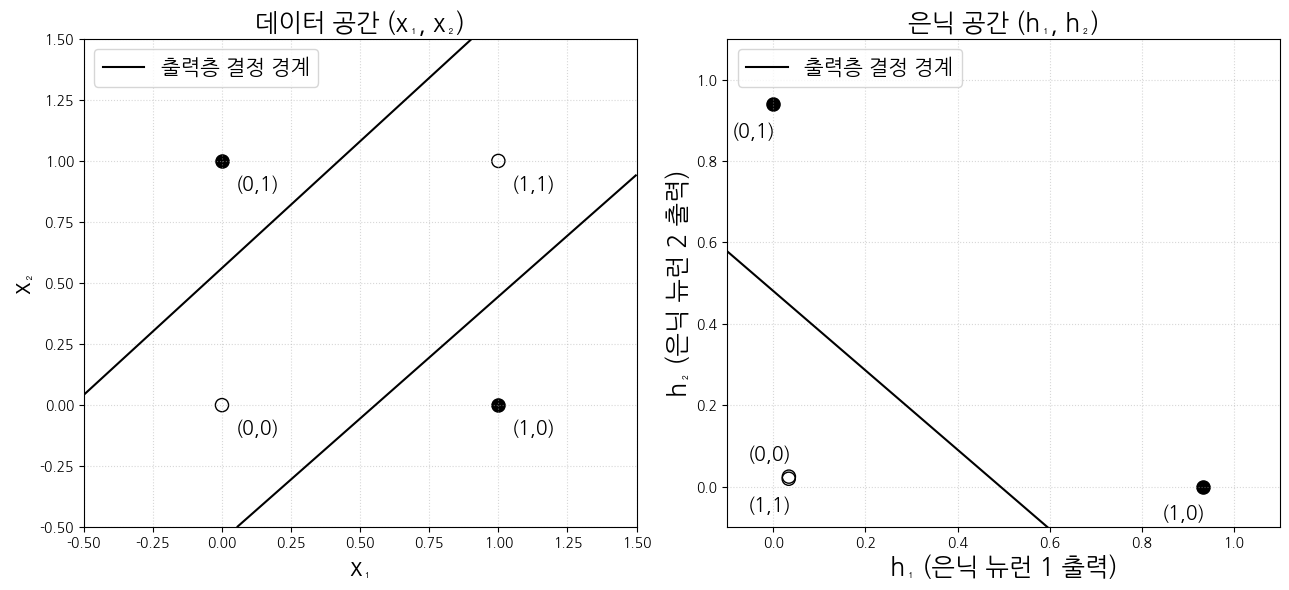

In [15]:
# 참고 - [그림 3-9] 정상 1 모델의 데이터 공간 + 은닉 공간 출력층 결정 경계
from matplotlib.lines import Line2D

# [그림 3-9]를 위한 정상 분류 모델 
normal_model = trained[1][2]

with torch.no_grad():
    hw = normal_model.hidden_layer.weight.detach()     # (2, 2)
    hb = normal_model.hidden_layer.bias.detach()       # (2,)
    ow = normal_model.output_layer.weight.detach()     # (1, 2)
    ob = normal_model.output_layer.bias.detach()       # (1,)
    hidden_out = torch.sigmoid(X @ hw.T + hb)          # 은닉 공간 좌표 (4, 2)
ow_np = ow.numpy().flatten()
ob_np = ob.numpy().flatten()
ho_np = hidden_out.numpy()

font_size = 18
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# (a) 데이터 공간: 입력 격자에서 모델 출력 0.5 등고선으로 결정 경계 표시
ax = axes[0]
grid_n = 200
xs = np.linspace(-0.5, 1.5, grid_n)
ys = np.linspace(-0.5, 1.5, grid_n)
XX, YY = np.meshgrid(xs, ys)
grid_pts = torch.tensor(
    np.stack([XX.ravel(), YY.ravel()], axis=1), dtype=torch.float32
)
normal_model.eval()
with torch.no_grad():
    grid_out = normal_model(grid_pts).numpy().reshape(grid_n, grid_n)
ax.contour(XX, YY, grid_out, levels=[0.5], colors='black', linewidths=1.5)
for x1, x2, y in zip([0., 1., 0., 1.], [0., 0., 1., 1.], Y_label_list):
    face = 'black' if y == 1 else 'none'
    ax.scatter(x1, x2, marker='o', s=90, edgecolor='black', facecolor=face)
    ax.text(x1 + 0.05, x2 - 0.12, f'({int(x1)},{int(x2)})', fontsize=14)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlabel('x₁', fontsize=font_size)
ax.set_ylabel('x₂', fontsize=font_size)
ax.set_title('데이터 공간 (x₁, x₂)', fontsize=font_size)
ax.legend(handles=[Line2D([0], [0], color='black', linewidth=1.5,
                          label='출력층 결정 경계')],
          loc='upper left', fontsize=15)
# (b) 은닉 공간: 4 개 점을 은닉층 출력 (h1, h2) 좌표로 배치 (출력층은 선형)
ax = axes[1]
h_range = np.linspace(-0.1, 1.1, 400)
if ow_np[1] != 0:
    h2_line = -(ow_np[0] / ow_np[1]) * h_range - (ob_np[0] / ow_np[1])
    ax.plot(h_range, h2_line, color='black', linewidth=1.5,
            label='출력층 결정 경계')
else:
    ax.axvline(-ob_np[0] / ow_np[0], color='black', linewidth=1.5,
               label='출력층 결정 경계')
# 은닉 공간의 각 점은 데이터 공간의 입력이 옮겨진 위치이므로
# 은닉 공간 좌표 대신 원래 입력 (x1, x2) 로 표시해 두 공간을 대응시킨다
for i, ((h1, h2), y) in enumerate(zip(ho_np, Y_label_list)):
    x1, x2 = X[i].tolist()
    face = 'black' if y == 1 else 'none'
    ax.scatter(h1, h2, marker='o', s=90, edgecolor='black', facecolor=face)
    if i == 0:
        ax.text(h1 - 0.09, h2 + 0.04, f'({int(x1)},{int(x2)})', fontsize=14)
    else:
        ax.text(h1 - 0.09, h2 - 0.08, f'({int(x1)},{int(x2)})', fontsize=14)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlabel('h₁ (은닉 뉴런 1 출력)', fontsize=font_size)
ax.set_ylabel('h₂ (은닉 뉴런 2 출력)', fontsize=font_size)
ax.set_title('은닉 공간 (h₁, h₂)', fontsize=font_size)
ax.legend(loc='upper left', fontsize=15)
fig.tight_layout()
# 회색조 300DPI PNG로 저장 (파일명: 03-02_example_02.png)
viz._save_grayscale(fig)
plt.show()

은닉 공간(은닉층 두 뉴런의 출력을 좌표로 삼은 평면)에서는 XOR 의 0 클래스 두 점과 1 클래스 두 점을 한 직선으로 분리할 수 있다. 원래 입력 공간에서는 직선으로 분리할 수 없던 문제를 은닉층이 새로운 좌표로 비틀어 두기 때문에, 출력층의 단일 직선 결정 경계로 풀리는 형태가 된다.

다음 절(3-3) 에서는 분포가 복잡하고 클래스가 셋 이상인 회오리 데이터 분류를 다룬다.